In [1]:
import os
import re
from tqdm import tqdm
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
import seaborn as sns

Ce notebook analyse les discours des députés regroupés par partis

In [2]:
import ast
with open('reduced2.txt',encoding='utf-8') as f:
    data=f.read()
discours1=ast.literal_eval(data)
f.close()

In [3]:
import ast
with open('reduced3.txt',encoding='utf-8') as f:
    data=f.read()
discours2=ast.literal_eval(data)
f.close()
del(discours2['Jean-Claude Sandrier'])

In [4]:
discours={**discours1,**discours2}

In [5]:
dep=pd.read_csv("C:\dalas\projet\deputes_reduced.csv")

In [7]:
dep['groupe_sigle'].unique()

array(['union pour un mouvement populaire', 'parti socialiste',
       'democratie et republique', 'nouveau centre', 'les republicains',
       'union des democrates et independants', 'parti radical de gauche',
       'la republique en marche', 'mouvement democrate',
       'alliance ecologiste independante', 'la france insoumise',
       'union pour la democratie francaise', 'renaissance',
       'rassemblement national', 'europe ecologie les verts', 'horizons'],
      dtype=object)

In [6]:
dep.loc[dep.index.isin(dep[dep['groupe_sigle']=='alliance ecologiste independante'].index),['groupe_sigle']]='les verts'

In [7]:
def change(name):
    if name=='socialistes, ecologistes et republicains' or name=='nouvelle gauche'or name=='socialiste, radical, citoyen et divers gauche':
        return 'parti socialiste'
    elif name=='radical, republicain, democrate et progressiste':
        return 'parti radical de gauche'
    elif name=='libertes, independants, outre-mer et territoires':
        return 'liberte et territoires'
    else:
        return name

In [8]:
df=pd.read_csv('fin_reduced2.csv')

In [9]:
df[df['nom parti']=='UNION POUR UN MOUVEMENT POPULAIRE'.lower()]['num parti'].unique()[0]

401

In [10]:
dep.drop(dep[dep['groupe_sigle']=='union pour la democratie francaise'].index,inplace=True)

In [11]:
dep.drop(dep[dep['groupe_sigle']=='democratie et republique'].index,inplace=True)

In [14]:
df['nom parti'].unique()

array(['front national', 'parti radical de gauche',
       'parti communiste francais', 'parti socialiste', 'les verts',
       'mouvement pour la france', 'ump', 'debout la republique',
       'mouvement democrate', 'nouveau centre', 'verts',
       "l'union pour un mouvement populaire",
       'association psle - nouveau centre', 'europe ecologie les verts',
       'union pour un mouvement populaire',
       'union des democrates et independants',
       'union pour un mouvement populaire ', 'debout la france',
       'les republicains', 'les centristes', 'en marche',
       'la republique en marche', 'la france insoumise',
       'rassemblement national', 'horizons', 'renaissance'], dtype=object)

In [12]:
dep['num groupe']=0

In [13]:
num={}
for i in dep['groupe_sigle'].unique():
    num[i]=df[df['nom parti']==i]['num parti'].unique()[0]

In [14]:
dep['num groupe']=dep['groupe_sigle'].map(num)

In [18]:
dep

,nom,date_naissance,num_deptmt,num_circo,groupe_sigle,place_en_hemicycle,nb_mandats,mandat,num groupe
0,Guy Teissier,1945-04-04,13,6,union pour un mouvement populaire,168.0,4,"[2007, 2008, 2009, 2010, 2011, 2012]",401
1,Jean Proriol,1934-11-25,43,2,union pour un mouvement populaire,331.0,2,"[2007, 2008, 2009, 2010, 2011, 2012]",401
2,Sandrine Hurel,1968-08-07,76,11,parti socialiste,633.0,2,"[2007, 2008, 2009, 2010, 2011, 2012]",76
3,Arlette Franco,1939-10-01,66,2,union pour un mouvement populaire,145.0,3,"[2007, 2008, 2009, 2010]",401
4,Pierre-Christophe Baguet,1955-05-11,92,9,union pour un mouvement populaire,291.0,2,"[2007, 2008, 2009, 2010, 2011, 2012]",401
...,...,...,...,...,...,...,...,...,...
2350,Alexandra Martin,1976-07-28,33,1,renaissance,439.0,0,"[2023, 2024]",910
2351,Ingrid Dordain,1978-03-18,80,2,renaissance,464.0,0,"[2023, 2024]",910
2353,Philippe Emmanuel,1960-06-08,78,10,renaissance,398.0,0,"[2023, 2024]",910
2354,René Pilato,1962-08-31,16,1,la france insoumise,520.0,0,"[2023, 2024]",976


In [15]:
dep.drop(columns=['nb_mandats','place_en_hemicycle'],inplace=True)

In [16]:
mots=['démocratie','populisme','écologie','immigration','souveraineté','égalité','sécurité','réforme','identité','justice sociale','libéralisme','nationalisme',
"droits de l'homme",'economie','santé publique','technologie','education','corruption','fédéralisme','diversité','religion','islam','catholique','juif','gouvernance',
'economie','société','environnement','administration','politique','législation','régulation','transparence','croissance', 'chômage', 'inflation', 'fiscalité', 'dette publique', 
'marché', 'capitalisme', 'socialisme','inégalités', 'pauvreté', 'solidarité', 'cohésion sociale', 'exclusion', 'intégration','société','changement climatique', 'développement durable', 
'biodiversité', 'énergie renouvelable', 'pollution','terrorisme', 'défense', 'armée', 'police', 'cyber sécurité', 'conflit','droits','liberté',"liberté d'expression", 'droits civiques', 
'discrimination', 'égalité des sexes', 'LGBTQ','santé', 'assurance maladie', 'épidémie', 'vaccination', 'prévention','innovation', 'intelligence artificielle', 'numérique', 'données personnelles', 
'surveillance','culture', 'patrimoine', 'identité culturelle', 'diversité culturelle', 'arts', 'médias','diplomatie', 'géopolitique', 'union européenne', 'globalisation', 'souveraineté', 'nation','justice',
'système judiciaire', 'victimes', 'peine de mort', 'réinsertion', 'corruption','punition','asile', 'réfugiés', 'frontières', 'intégration', 'xénophobie','laïcité', 'culte', 'extrémisme','décentralisation', 'régionalisation', 
'autonomie', 'centralisation']

In [17]:
over=[]
for i in discours:
    for j in discours[i]:
        for k in discours[i][j]:
            if not k in mots:
                over.append((i,j,k))
for (i,j,k) in over:
    del discours[i][j][k]

In [18]:
all_years = set()
all_mots = set()

for mots_par_annee in discours.values():
    for annee, mots in mots_par_annee.items():
        all_years.add(int(annee))
        all_mots.update(mots.keys())

all_years = sorted(all_years)

In [19]:

from collections import defaultdict
grouped_data = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))

for _, row in dep.iterrows():
    nom = row["nom"]
    num_groupe = row["num groupe"]
    
    if nom not in discours:  # nom pas dans les données de mots
        continue
    
    mots_par_annee = discours[nom]
    
    for annee, mots in mots_par_annee.items():
        for mot, occ in mots.items():
            grouped_data[num_groupe][mot][annee] += occ

# Maintenant on convertit en DataFrame par groupe
grouped_dfs = {}

for groupe, mots_dict in grouped_data.items():
    df_groupe = pd.DataFrame(mots_dict).T
    df_groupe = df_groupe.reindex(columns=all_years, fill_value=0)
    df_groupe = df_groupe.fillna(0).astype(int)
   # for i in df_groupe:
    #    df_groupe[i]=df_groupe[i]/df_groupe[i].sum()
    #df_groupe = df_groupe.reindex(sorted(df_groupe.columns), axis=1)
    grouped_dfs[groupe] = df_groupe.drop(columns=[2000,2001,2002,2003,2004,2005,2023,2024,2025])

In [20]:
df_unique = df.drop_duplicates(subset=["nom parti", "num parti"])

In [21]:
norm={}
for i in grouped_dfs:
    normi=pd.DataFrame()
    for j in grouped_dfs[i]:
        normi[j]=grouped_dfs[i][j]/grouped_dfs[i][j].sum()
    norm[i]=normi

In [22]:
del(norm[1344])

In [23]:
def harmonize_word_year_dfs(dfs_dict):
    # 1. Récupérer tous les mots et années existants
    all_mots = set()
    all_annees = set()

    for df in dfs_dict.values():
        all_mots.update(df.index)
        all_annees.update(df.columns)

    all_mots = sorted(all_mots)
    all_annees = sorted(all_annees)

    # 2. Réindexer tous les DataFrames sur ces dimensions, en remplissant avec 0
    harmonized_dict = {}

    for key, df in dfs_dict.items():
        df_harmonized = df.reindex(index=all_mots, columns=all_annees, fill_value=0)
        harmonized_dict[key] = df_harmonized

    return harmonized_dict
new_dic=harmonize_word_year_dfs(norm)

In [24]:
with open('figaro.txt') as f:
    data=f.read()
dat=data.replace('Ã©','é').replace('ï¿½','é')
fig = ast.literal_eval(dat) 

with open('le_monde.txt') as f:
    data=f.read()
monde = ast.literal_eval(data) 

with open('libe.txt',encoding='utf-8') as f:
    data=f.read()
libe=ast.literal_eval(data)

x=list(libe.keys())
l=list(monde.keys())

for i,j in enumerate(l):
    monde[x[i]]=monde.pop(j)
x=list(libe.keys())
l=list(fig.keys())

for i,j in enumerate(l):
    fig[x[i]]=fig.pop(j)

years=[2005+i for i in range(18)]
rows = []

for word, occurrences in fig.items():
    row = {"mot": word}
    row.update({year: 0 for year in years})  
    
    for year, count in occurrences:
        row[year] = count
    
    rows.append(row)

df_fig = pd.DataFrame(rows).drop(columns=[2005])
rows = []
for word, occurrences in monde.items():
    row = {"mot": word}
    row.update({year: 0 for year in years})  
    
    for year, count in occurrences:
        row[year] = count
    
    rows.append(row)

df_monde = pd.DataFrame(rows).drop(columns=[2005])
rows = []
for word, occurrences in libe.items():
    row = {"mot": word}
    row.update({year: 0 for year in years})  
    
    for year, count in occurrences:
        row[year] = count
    
    rows.append(row)

df_libe = pd.DataFrame(rows).drop(columns=[2005,2023,2024])


In [25]:
df_libe = df_libe.set_index("mot")
df_fig = df_fig.set_index("mot")
df_monde = df_monde.set_index("mot")

In [26]:
norm_monde=pd.DataFrame()
for i in df_monde:
    norm_monde[i]=df_monde[i]/df_monde[i].sum()

norm_libe=pd.DataFrame()
for i in df_libe:
    norm_libe[i]=df_libe[i]/df_libe[i].sum()

norm_fig=pd.DataFrame()
for i in df_fig:
    norm_fig[i]=df_fig[i]/df_fig[i].sum()

In [27]:
from scipy.spatial.distance import cosine

def cosine_comp(df1,df2):
    commune=[a for a in df1.columns if df1[a].sum()>0 and df2[a].sum()>0]
    df1_com=df1[commune]
    df2_com=df2[commune]
    return(cosine(df1_com.values.flatten(),df2_com.values.flatten()))

In [28]:
name={}
for i in range(len(df_unique)):
    name[df_unique.iloc[i]['num parti']]=df_unique.iloc[i]['nom parti']

In [29]:
labels = list(new_dic.keys())
dist_mat = pd.DataFrame(index=labels, columns=labels, dtype=float)

for k, i in enumerate(labels):
    for j in labels:
        if i == j:
            dist = 0.0  # distance à soi-même
        else:
            dist = cosine_comp(new_dic[i], new_dic[j])
        dist_mat.loc[i, j] = 1-dist

dist_mat_named = dist_mat.copy()
dist_mat_named.index = [name.get(k, k) for k in dist_mat.index]
dist_mat_named.columns = [name.get(k, k) for k in dist_mat.columns]

c:\Users\math\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\spatial\distance.py:647: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
c:\Users\math\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\spatial\distance.py:647: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


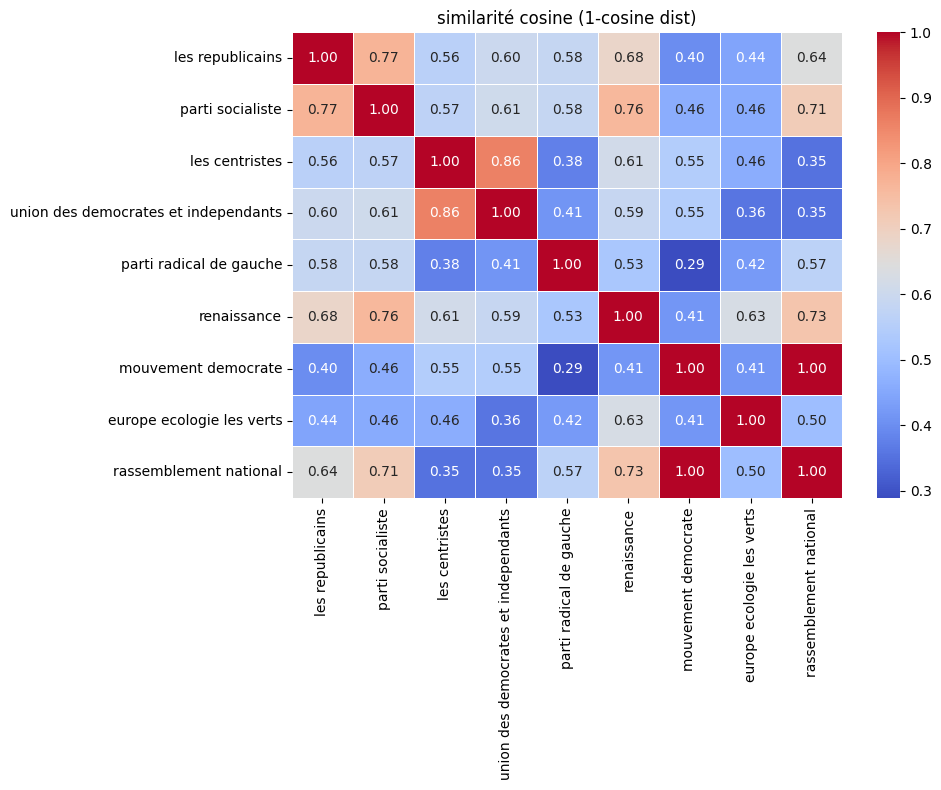

In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(dist_mat_named.astype(float), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("similarité cosine (1-cosine dist)")

plt.tight_layout()
plt.show()

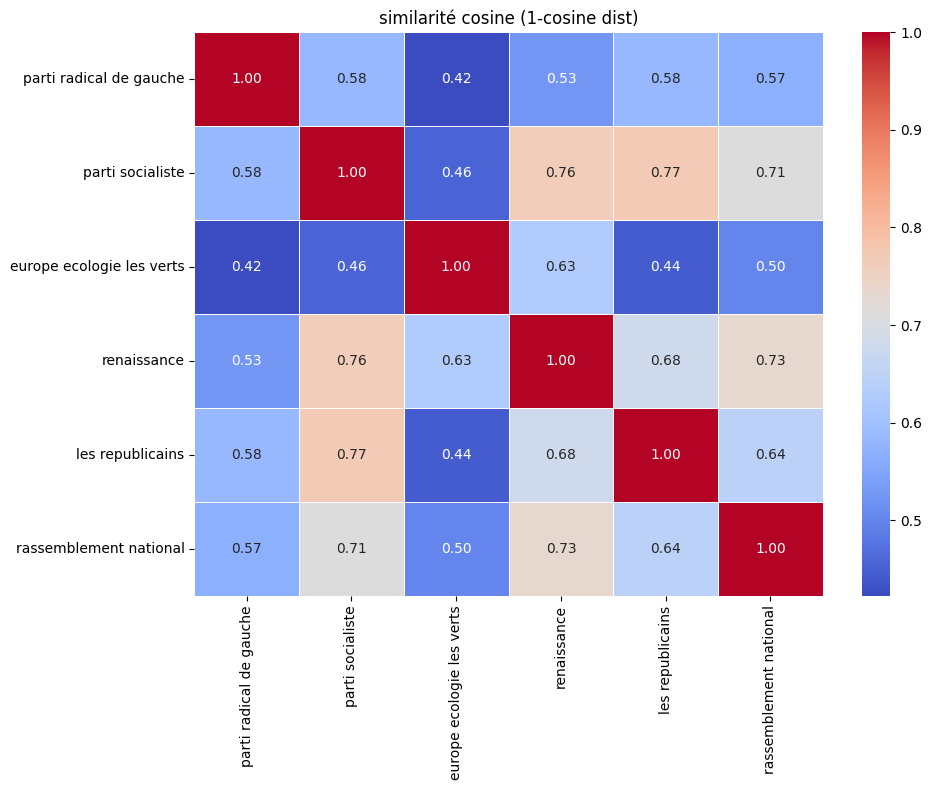

In [41]:
plt.figure(figsize=(10, 8))
reord=dist_mat_named.drop(labels=['les centristes','union des democrates et independants','mouvement democrate'],axis=1).drop(labels=['les centristes','union des democrates et independants','mouvement democrate'],axis=0)
reord=reord.iloc[:,[2,1,4,3,0,5]]
reord=reord.reindex(index=['parti radical de gauche','parti socialiste','europe ecologie les verts','renaissance','les republicains','rassemblement national'])
reord
sns.heatmap(reord.astype(float), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("similarité cosine (1-cosine dist)")

plt.tight_layout()
plt.show()

In [34]:
mots=list(set(df_monde.index)-set(new_dic[401].index))

In [35]:
df_fig.drop(mots,inplace=True)
df_libe.drop(mots,inplace=True)
df_monde.drop(mots,inplace=True)

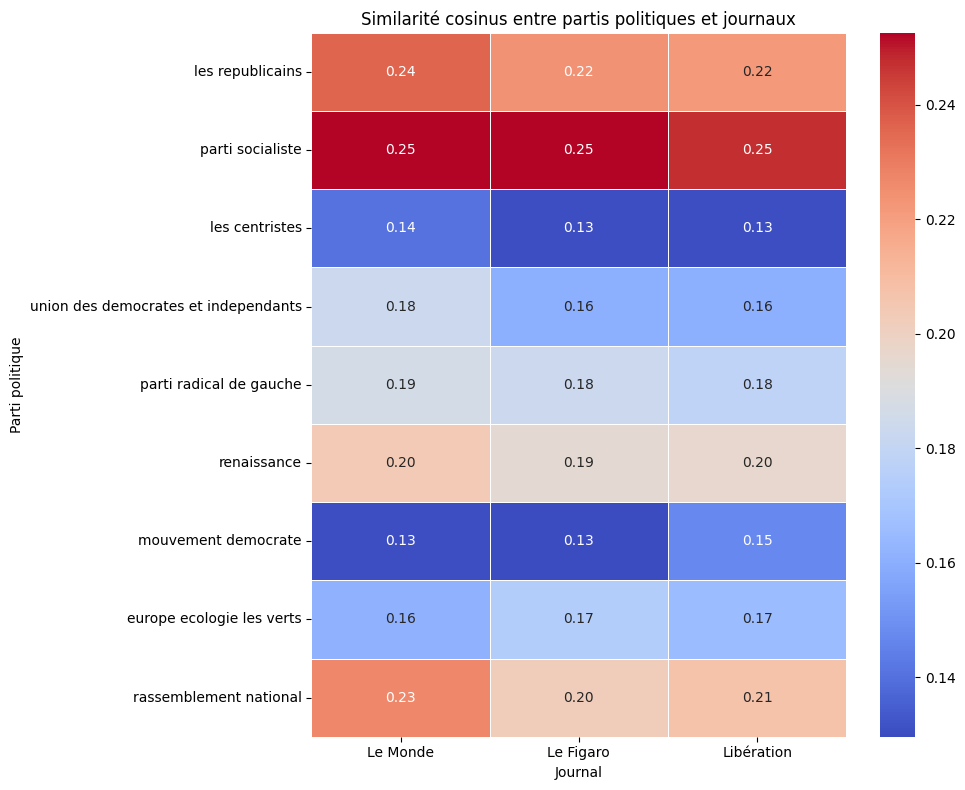

In [36]:
journaux = {
    "Le Monde": df_monde,
    "Le Figaro": df_fig,
    "Libération": df_libe
}

# Initialisation de la matrice
partis = list(new_dic.keys())
media = list(journaux.keys())
similarite_mat = pd.DataFrame(index=partis, columns=media, dtype=float)

# Calcul des similarités cosinus
for parti in partis:
    for journal_nom, journal_df in journaux.items():
       # print(journal_df)
        dist = cosine_comp(new_dic[parti], journal_df)
        similarite = 1 - dist
        similarite_mat.loc[parti, journal_nom] = similarite

# Optionnel : renommer les lignes avec des noms lisibles
similarite_mat.index = [name.get(p, p) for p in similarite_mat.index]

# Affichage de la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarite_mat.astype(float), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Similarité cosinus entre partis politiques et journaux")
plt.ylabel("Parti politique")
plt.xlabel("Journal")
plt.tight_layout()
plt.show()

In [41]:
new_dic[401]#[[2020,2021,2022]]

,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
administration,0.007486,0.012137,0.011366,0.020333,0.012951,0.004624,0.003255,0.007432,0.015028,0.021077,0.047115,0.039779,0.018158,0.024023,0.013158,0.018018,0.002378
armée,0.007121,0.006914,0.016523,0.007517,0.010583,0.005168,0.004557,0.000000,0.001219,0.000000,0.000000,0.000000,0.001946,0.000471,0.000000,0.006006,0.013080
arts,0.000000,0.000768,0.001052,0.003081,0.001114,0.001224,0.000000,0.000000,0.000000,0.002342,0.001442,0.000000,0.000000,0.016486,0.014254,0.000000,0.000000
asile,0.000000,0.002151,0.001894,0.000863,0.004456,0.000816,0.000000,0.000000,0.000000,0.003513,0.000000,0.002210,0.001946,0.000000,0.000000,0.021021,0.019025
autonomie,0.003652,0.021048,0.010419,0.010967,0.007381,0.007888,0.005859,0.004129,0.002437,0.005855,0.000962,0.000000,0.003243,0.008008,0.002193,0.018018,0.014269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
victimes,0.010955,0.005992,0.006525,0.012939,0.007520,0.010200,0.017578,0.007432,0.005280,0.022248,0.006731,0.001105,0.011673,0.016957,0.012061,0.021021,0.010702
xénophobie,0.000548,0.000461,0.000000,0.000123,0.000418,0.000000,0.000651,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
écologie,0.000548,0.003534,0.002315,0.003204,0.002646,0.001768,0.000651,0.000000,0.000000,0.003903,0.007212,0.003315,0.005188,0.009892,0.002193,0.000000,0.001189
égalité,0.023553,0.034414,0.007472,0.011707,0.012951,0.004488,0.007161,0.061932,0.018278,0.012881,0.039423,0.043094,0.027886,0.016015,0.012061,0.003003,0.005945


c:\Users\math\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\spatial\distance.py:647: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
c:\Users\math\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\spatial\distance.py:647: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
c:\Users\math\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\spatial\distance.py:647: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
c:\Users\math\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\spatial\distance.py:647: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
c:\Users\math\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\spatial\distance.py:647: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


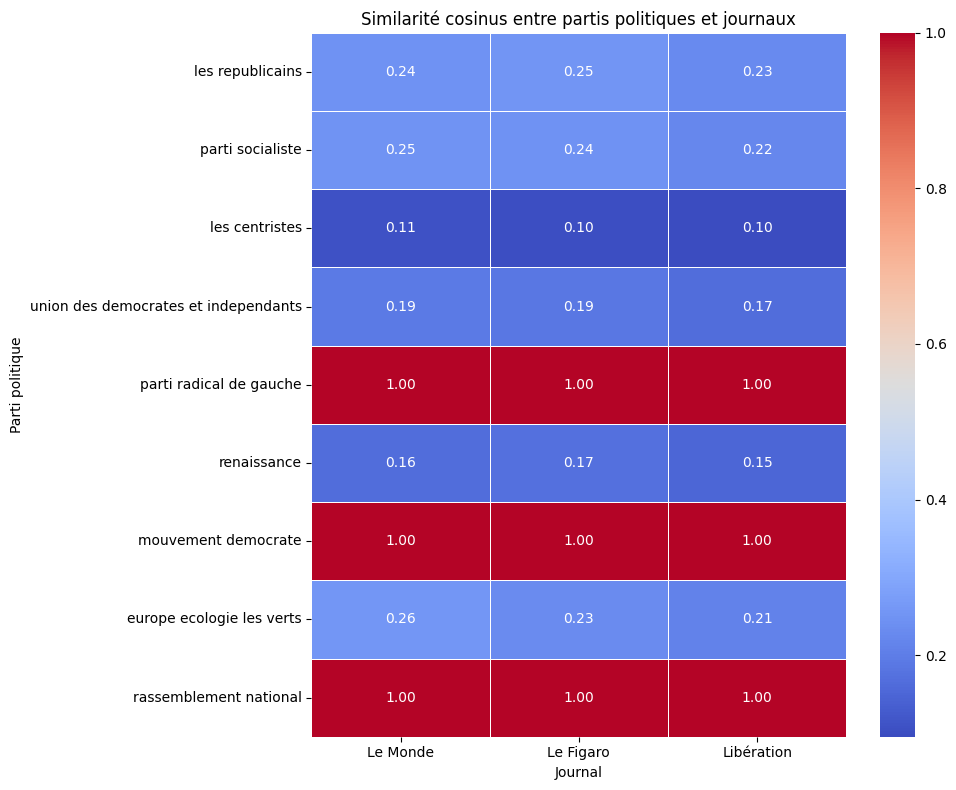

In [38]:
journaux = {
    "Le Monde": df_monde,
    "Le Figaro": df_fig,
    "Libération": df_libe
}

# Initialisation de la matrice
partis = list(new_dic.keys())
media = list(journaux.keys())
similarite_mat = pd.DataFrame(index=partis, columns=media, dtype=float)

# Calcul des similarités cosinus
for parti in partis:
    for journal_nom, journal_df in journaux.items():
       # print(journal_df)
        dist = cosine_comp(new_dic[parti][[i for i in range(2008,2012)]], journal_df[[i for i in range(2008,2012)]])
        similarite = 1 - dist
        similarite_mat.loc[parti, journal_nom] = similarite

# Optionnel : renommer les lignes avec des noms lisibles
similarite_mat.index = [name.get(p, p) for p in similarite_mat.index]

# Affichage de la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarite_mat.astype(float), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Similarité cosinus entre partis politiques et journaux")
plt.ylabel("Parti politique")
plt.xlabel("Journal")
plt.tight_layout()
plt.show()

In [39]:
df_unique

,num parti,nom parti,année,immobilisations incorporelles,écarts d'acquisition,terrains et constructions,autres immobilisations corporelles,participations et créances rattachées,prêts à des partis ou groupements politiques,autres immobilisations financières,...,dévolutions de partis ou groupements politiques,prestations de services (manifestations et colloques),"ventes de marchandises, productions vendue (biens et services), production stockée et production immobilisée",total iii,total v,"reprise sur amortissements, dépréciations, provisions et transferts de charges",total des produits (i + iii + v),excédent ou déficit d'ensemble,total flux,deputes
0,40,front national,2008,24537,0,4198171,741272,14000,717658,93728,...,15000,196224,206599,45986,86966,163809,3854207,-2445426,10153840,0
1,52,parti radical de gauche,2008,0,0,76225,74503,0,0,73793,...,418225,22871,95534,18376,234,0,2047197,35293,4059101,0
2,60,parti communiste francais,2008,0,0,6070376,695940,103251,11494547,51696,...,0,777259,1960503,272132,250770,389767,31559485,725272,62393698,24
3,76,parti socialiste,2008,245377,0,14048629,2574300,1348989,1767573,492160,...,89885,739962,3359598,470816,712047,2192099,59166852,17139,118316565,204
4,104,les verts,2008,23465,0,0,2221669,103665,0,401382,...,6000,128265,286247,23892,158579,81592,5166761,439834,9893688,3
5,177,mouvement pour la france,2008,0,0,0,14692,15,0,23269,...,0,20616,251838,12454,0,0,1612259,195011,3029507,2
6,401,ump,2008,299944,0,1146947,1224247,0,1319305,934604,...,178332,686444,1043872,63816,102616,313417,52108172,10304531,93911813,321
7,410,debout la republique,2008,538,0,0,27555,0,0,3000,...,126000,19780,9842,476,0,0,316551,96131,536971,2
8,529,mouvement democrate,2008,0,0,0,3045,0,48500,508,...,0,169199,163773,14678,0,0,5619168,877814,10360522,4
9,531,nouveau centre,2008,8084,0,0,55652,0,0,15348,...,1194060,94116,71234,0,0,0,1517135,221687,2812583,23


In [ ]:
new_dic

{'Jean-Claude Sandrier': {2007: {'solidarité': 6,
   'croissance': 20,
   'réforme': 6,
   'politique': 12,
   'pauvreté': 7,
   'catholique': 1,
   'inégalités': 13,
   'société': 4,
   'patrimoine': 5,
   'sécurité': 18,
   'chômage': 2,
   'nation': 2,
   'capitalisme': 5,
   'démocratie': 2,
   'justice': 5,
   'victimes': 1,
   'diversité': 1,
   'liberté': 2,
   'égalité': 4,
   'libéralisme': 1,
   'santé': 7,
   'conflit': 1,
   'immigration': 1,
   'culture': 3,
   'environnement': 3,
   'droits': 4,
   'inflation': 2,
   'écologie': 1,
   'fiscalité': 1,
   'marché': 4,
   'autonomie': 1,
   'economie': 1,
   'education': 2,
   'souveraineté': 1},
  2009: {'chômage': 7,
   'capitalisme': 14,
   'marché': 2,
   'liberté': 6,
   'politique': 23,
   'société': 2,
   'santé': 9,
   'education': 1,
   'sécurité': 1,
   'environnement': 4,
   'inégalités': 2,
   'croissance': 6,
   'fiscalité': 1,
   'culture': 1,
   'justice': 4,
   'solidarité': 1,
   'égalité': 1,
   'droits': 8